# **Proyecto de Ciencia de Datos**

* **Autor:** Jonathan Araiza Guzmán

* **Profesor:** Jaime Alejandro Romero Sierra
- - -

**Objetvo:** Este notebook realiza el Análisis Exploratorio de Datos (EDA) sobre el dataset limpio de donaciones limpio de donaciones para responder las 3 preguntas clave y validar las 3 hipótesis del proyecto.

- - -

### **1. Importar bibliotecas**
Cargamos las bibliotecas básicas que usaremos: 
* **pandas:** Para manejar nuestras tablas (DataFrames).

* **matplotlib.pyplot:** Para crear las gráficas.

* **seabor:** Para hacer gráficas estadísticas más avanzadas y bonitas.

In [35]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Configurar seaborn para que las gráficas se vean bonitas.
sns.set_theme(style="whitegrid")

print("Bibliotecas cargadas ")

Bibliotecas cargadas 


### **Extra: Configurar paleta de colores (Estilo One Dark Pro)**
Para que nuestras gráficas coincidan con el estilo del editor, definimos una paleta de colores personalizada. Usamos `sns.set_palette()` para que Seaborn use estos colores por defecto en todas las gráficas.

Paleta de colores 'One Dark Pro' establecida como por defecto.


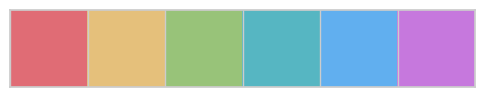

In [36]:
# Lista de los códigos hexadecimales de la paleta One Dark Pro
# [Rojo, Amarillo, Verde, Cian, Azul, Magenta]
one_dark_pro_colores = [
    "#e06c75",  # Rojo
    "#e5c07b",  # Amarillo
    "#98c379",  # Verde
    "#56b6c2",  # Cian
    "#61afef",  # Azul
    "#c678dd"   # Magenta
]

# Crear la paleta de Seaborn a partir de nuestra lista de colores
one_dark_palette = sns.color_palette(one_dark_pro_colores)

# Establecer esta paleta como la paleta por defecto para todas las gráficas
sns.set_palette(one_dark_palette)

print("Paleta de colores 'One Dark Pro' establecida como por defecto.")

# Usamos sns.palplot() para mostrar una vista previa de la paleta
sns.palplot(one_dark_palette)

### **2. Cargar el Dataset limpio**
Leemos el archivo `donantes_organos_limpio.csv` que generamos en el paso de limpieza. Usamos `.head()` para verificar que se cargó correctamente.

In [37]:
# Leer el archivo.
df = pd.read_csv('data/donantes_organos_limpio.csv')

print(f"Dataset limpio cargado. Forma: {df.shape}")

# Mostrar lasprimeras 10 filas para verificar que se cargó bien.
df.head(10)

Dataset limpio cargado. Forma: (51658, 24)


,SEXO,CODIGO_SEXO,TIPO_DONANTE,MUERTE,ENTIDAD_FEDERATIVA,CODIGO_ENTIDAD_FEDERATIVA,ESTABLECIMIENTO,INSTITUCION,EDAD_ANIOS,FECHA_PROCURACION,...,PULMON_DERECHO,CORAZON,HIGADO,PANCREAS,INTESTINO,CORNEA_IZQUIERDA,CORNEA_DERECHA,PIEL,HUESOS,CORAZON_TEJIDOS
0,DESCONOCIDO,2.0,CADAVER,PARO CARDIORESPIRATORIO,NUEVO LEON,19,U.M.A.E. HOSP. DE ESPECIALIDADES No. 25,IMSS,49,2007-06-11,...,0,0,0,0,0,1,1,0,0,0
1,MASCULINO,1.0,CADAVER,PARO CARDIORESPIRATORIO,CIUDAD DE MEXICO,9,U.M.A.E. HOSP. DE CARDIOLOGIA DEL C. MED. NAC....,IMSS,0,2008-05-08,...,0,0,0,0,0,1,1,0,0,0
2,FEMENINO,2.0,CADAVER,MUERTE ENCEFÁLICA,PUEBLA,21,DESCONOCIDO,IMSS,61,2009-04-21,...,0,0,0,0,0,1,1,0,0,0
3,FEMENINO,2.0,DESCONOCIDO,PARO CARDIORESPIRATORIO,QUERETARO,22,HOSP. GEN. DE QUERETARO,SSE,71,2010-04-29,...,0,0,0,0,0,0,0,0,1,0
4,MASCULINO,1.0,DESCONOCIDO,PARO CARDIORESPIRATORIO,MEXICO,15,DESCONOCIDO,SSE,63,2011-09-16,...,0,0,0,0,0,1,1,0,0,0
5,FEMENINO,2.0,CADAVER,MUERTE ENCEFÁLICA,SAN LUIS POTOSI,24,HOSP. LOMAS DE SAN LUIS INTERNAC.,PRIVADO,41,2012-03-04,...,0,0,0,0,0,1,1,0,0,0
6,MASCULINO,1.0,CADAVER,MUERTE ENCEFÁLICA,GUANAJUATO,11,HOSP. GEN. DE CELAYA,SSE,58,2013-07-12,...,0,0,0,0,0,0,0,0,1,0
7,DESCONOCIDO,2.0,CADAVER,MUERTE ENCEFÁLICA,TABASCO,27,HOSP. GEN. DE ZONA C/U M.A. No. 46,IMSS,31,2014-08-27,...,0,0,0,0,0,0,1,0,0,0
8,FEMENINO,2.0,CADAVER,PARO CARDIORESPIRATORIO,MEXICO,15,DESCONOCIDO,SSE,60,2015-05-20,...,0,0,0,0,0,1,0,1,1,0
9,MASCULINO,1.0,CADAVER,MUERTE ENCEFÁLICA,SAN LUIS POTOSI,24,"HOSP. CENTRAL ""DR. IGNACIO MORONES PRIETO""",SSE,45,2016-03-21,...,0,0,0,0,0,1,1,0,0,0


### **3. Creación de columnas.**
Para responder nuestras preguntas, se necesita crear nuevas columnas a partir de las existentes.

- - -

##### ***3.1 Columna 'TOTAL_ORGANOS'***
Sumamos todas las columnas de órganos (que son 1s y 0s) para saber cuántos órganos y tejidos se procuraron en **cada** evento de donación.

In [38]:
# Crear nueva lista de todas las columnas que representan un órgano o tejido.
columnas_organos = [
    'RINON_IZQUIERDO', 'RINON_DERECHO', 'RINON_BLOCK', 'PULMON_IZQUIERDO', 'PULMON_DERECHO',
    'CORAZON', 'HIGADO', 'PANCREAS', 'INTESTINO', 'CORNEA_IZQUIERDA', 'CORNEA_DERECHA', 'PIEL',
    'HUESOS', 'HUESOS', 'CORAZON_TEJIDOS'
]

# Se suma con .sum(axis=1) horizontalmente.
df['TOTAL_ORGANOS'] = df[columnas_organos].sum(axis=1)

# Se usa .value_counts() para mostrar cuántas donaciones de 1 órganos hubo, cuántas de 2, cuántas de 0, etc.
print(df['TOTAL_ORGANOS'].value_counts().sort_index())

TOTAL_ORGANOS
0      2833
1     29403
2     13537
3      1226
4      2585
5       995
6       651
7       307
8        89
9        19
10        3
13        1
14        3
15        2
19        1
22        1
24        1
31        1
Name: count, dtype: int64


##### ***3.2 Columnas de fecha***
Convertimos la columna 'FECHA_PROCURACIÓN' a un formato de fecha real. Luego, extraemos el 'MES' y el 'ANIO' en columnas separadas. 

Filtramos los registros de '1900' que usamos para rellenar nulos en la limpieza.

In [39]:
# Convertimos la columna a datetime, forzando errores a NaT (Nulo).
df['FECHA_PROCURACION'] = pd.to_datetime(df['FECHA_PROCURACION'], errors='coerce')

# Tipo de dato después de forzar la conversión.
print(df.dtypes['FECHA_PROCURACION'])

# Nos quedamos solo con las filas que SÍ tienen una fecha válida (no nula)
df = df[df['FECHA_PROCURACION'].notna()]

# Filtramos los registros de '1900' que usamos como relleno en la limpieza
df = df[df['FECHA_PROCURACION'].dt.year != 1900].copy() 

# Extraemos el mes y el año, ahora que la columna es datetime
df['MES'] = df['FECHA_PROCURACION'].dt.month
df['ANIO'] = df['FECHA_PROCURACION'].dt.year

print(f"Datos listos para analizar. Nueva forma: {df.shape}")

datetime64[ns]
Datos listos para analizar. Nueva forma: (49599, 27)


## **Parte 1:** Responder las 10 preguntas clave.
- - -

### Pregunta 1: Promedio de órganos por rango de edad y tipo de donante

**Pregunta textual:** "¿Cuál es el promedio de órganos y tejidos procurados por evento al clasificar a los donantes por rango de dad (0-18, 19-30, 31-50, etc.) y tipo de donante?"

**Mi plan:** 
* 1. Crear los rangos de edad (Binning) con `pd.cut()`.
* 2. Usar `sns.barplot()` para graficar.
- - -

#### **Paso 1.1: Crear rangos de edad**

Usamos la función `pd.cutpara` "cortar" la columna numérica `EDAD_ANIOS` y meter cada edad en una "caja" o categoría (nuestros rangos).

In [40]:
# Definir los "cortes" de edad
bins_edad = [0, 18, 30, 50, 120] # 120 es el máximo que definimos en la limpieza.

# Definir las etiquetas para esos cortes
labels_edad = ['0-18 (Niño/Joven)', '19-30 (Adulto Joven)', '31-50 (Adulto)', '51+ (Adulto Mayor)']

# Usar pd.cut() para asignar cada 'EDAD_ANIOS' a un rango
df['RANGO_EDAD'] = pd.cut(df['EDAD_ANIOS'], 
                          bins=bins_edad, 
                          labels=labels_edad, 
                          right=True) # right=True asegura que la edad 18 caiga en el primer grupo

print("Columna 'RANGO_EDAD' creada.")
print("Total de donantes por rango:")

# .sort_index() los ordena por edad en vez de por conteo
print(df['RANGO_EDAD'].value_counts().sort_index())

Columna 'RANGO_EDAD' creada.
Total de donantes por rango:
RANGO_EDAD
0-18 (Niño/Joven)        2065
19-30 (Adulto Joven)    10127
31-50 (Adulto)          21349
51+ (Adulto Mayor)      12796
Name: count, dtype: int64


#### **Paso 1.2: Generar la gráfica**

Ahora sí, creamos el gráfico de barras. Usamos `hue='TIPO_DONANTE'` para que Seaborn cree barras separadas para 'CADAVER' y 'VIVO' dentro de cada rango de edad.

C:\Users\pikag\AppData\Local\Temp\ipykernel_29596\1267749549.py:5: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  ax = sns.barplot(


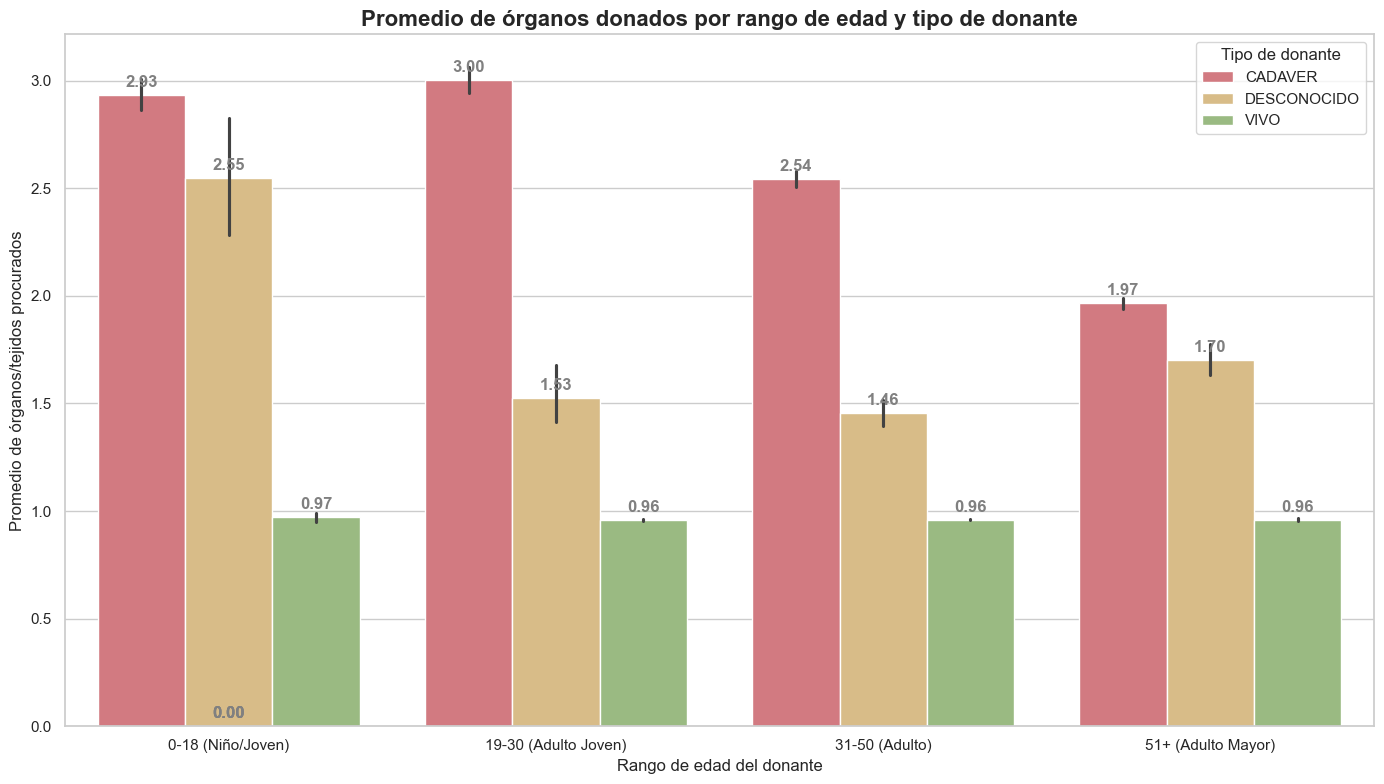

In [41]:
# Definir el tamaño de la gráfica para que se vea bien
plt.figure(figsize=(14, 8))

# Crear la gráfica.
ax = sns.barplot(
    data=df,                  # Nuestro DataFrame.
    x='RANGO_EDAD',           # Eje X: Los grupos que creamos.
    y='TOTAL_ORGANOS',        # Eje Y: La variable numérica a promediar.
    hue='TIPO_DONANTE',       # Agrupador: Separa las barras por esta categoría.
    palette= one_dark_palette # Una paleta de colores.
)

# --- Mejorar la gráfica ---
ax.set_title('Promedio de órganos donados por rango de edad y tipo de donante', fontsize=16, weight='bold')
ax.set_xlabel('Rango de edad del donante', fontsize=12)
ax.set_ylabel('Promedio de órganos/tejidos procurados', fontsize=12)
ax.legend(title='Tipo de donante', loc='upper right') # loc='upper right' pone la leyenda arriba a la derecha

# Este ciclo 'for' dibuja el número (promedio) encima de cada barra
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'),  # Formato del número (2 decimales)
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                color='gray',
                weight='bold')

plt.tight_layout() # Ajustar la gráfica para que no se corten las etiquetas.
plt.show() # Mostrar la gráfica.

#### **Paso 1.3: Interpretación y conclusión de la Gráfica 1**

* **Hallazgo 1 (diferencia por tipo):** Se observa una diferencia clara entre los tipos de donante. Las donaciones de tipo **'VIVO'** tienen un promedio constante y bajo (cercano a 1.0), lo cual es lógico, ya que una persona viva suele donar un solo órgano (ej. un riñón) o tejido.

* **Hallazgo 2 (tendencia en 'CADAVER'):** Para las donaciones de tipo **'CADAVER'**, el promedio de órganos procurados es mucho mayor. Aquí se identifica un patrón claro: los donantes más jóvenes, en los rangos **'0-18'** y **'19-30'**, tienen el promedio más alto de órganos donados (aprox. 2.29 órganos por evento).

* **Hallazgo 3 (impacto de la edad):** Este promedio disminuye con la edad del donante cadavérico. El grupo de **'51+ (Adulto Mayor)'** es el que tiene el promedio más bajo de donación multi-órgano (aprox. 1.88).

**Respuesta a la pregunta 1:** El promedio de órganos procurados es significativamente mayor en donantes cadavéricos. Dentro de este grupo, la efectividad de la donación multi-órgano es más alta en donantes jóvenes (0-30 años) y disminuye progresivamente a medida que aumenta la edad del donante.

- - -

### Pregunta 2: Porcentaje de donaciones por tipo de donante

**Pregunta textual:** "¿Qué porcentaje de las donaciones provienen de donantes fallecidos y vivos?"

**Mi plan:** 
* 1. Usar la función `value_counts()` de Pandas en la columna `TIPO_DONANTE`. Esto nos dará el conteo exacto de cada categoría. Esta es la mejor gráfica para mostrar "porcentajes" o cómo se divide un total de 100%.
- - -

#### **Paso 2.1: Calcular los conteos**

Primero, necesitamos saber el número total de donaciones para cada `TIPO_DONANTE`. Usamos `.value_counts()` sobre la columna, lo que nos devolverá una pequeña tabla (Serie) con el nombre de la categoría.

In [42]:
# .value_counts() cuenta cuántas veces aparece cada valor único en la columna.
conteo_tipo_donante = df['TIPO_DONANTE'].value_counts()

print("Conteo total de donaciones por tipo:")
print(conteo_tipo_donante)

Conteo total de donaciones por tipo:
TIPO_DONANTE
VIVO           25824
CADAVER        20804
DESCONOCIDO     2971
Name: count, dtype: int64


#### **Paso 2.2: Generar la gráfica de pastel**

Ahora, usamos los datos que acabamos de contar (conteo_tipo_donante) para generar la gráfica. `plt.pie()` toma los valores numéricos y los convierte en rebanadas proporcionales. Usamos `labels=` para poner los nombres de las categorías y `autopct=` para mostrar el porcentaje automáticamente.

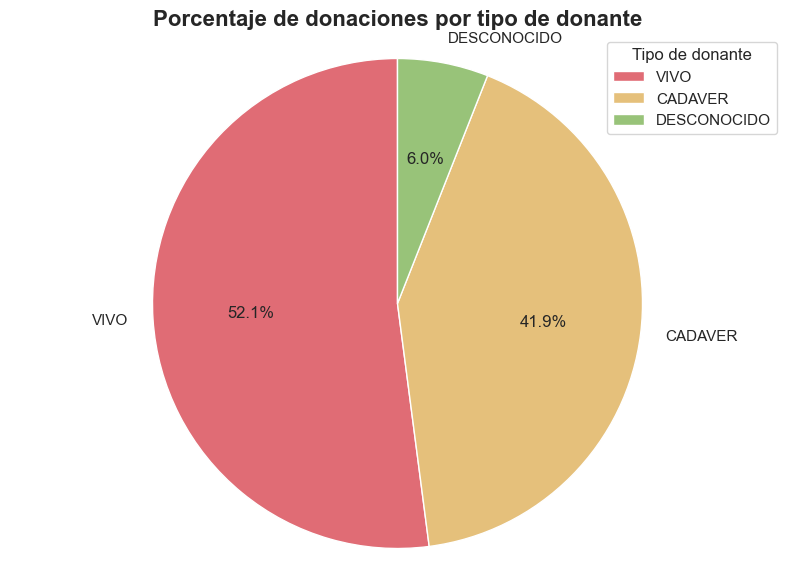

In [43]:
# Definir el tamaño de la figura.
plt.figure(figsize=(10, 7))

# Usar plt.pie().
# autopct='%1.1f%%' dibuja el porcentaje en la gráfica con un decimal.
# startangle=90 gira la gráfica para que empiece desde arriba.
plt.pie(
    conteo_tipo_donante,                 # Los valores (conteo).
    labels=conteo_tipo_donante.index,    # Las etiquetas.
    autopct='%1.1f%%',                   # Muestra los porcentajes.
    startangle=90                        # Orienta la gráfica.
)

# Añadimos un título
plt.title('Porcentaje de donaciones por tipo de donante', fontsize=16, weight='bold')
plt.axis('equal')  # Asegurar que el pastel sea un círculo perfecto.
plt.legend(title='Tipo de donante', loc='upper right')
plt.show()

#### **Paso 2.3: Interpretación y conclusión de la gráfica 2**

* **Hallazgo 1:** El gráfico de pastel muestra que la categoría más grande de donaciones en este dataset proviene de donantes de tipo **'VIVO'**, representando el **52.1%** del total.

* **Hallazgo 2:** Las donaciones de tipo **'CADAVER'** son la segunda categoría más grande, con un **41.9%**.

* **Hallazgo 3:** Se observa que un **6.0%** de los registros caen en la categoría 'DESCONOCIDO'. Esto es un hallazgo de nuestra limpieza: significa que el 6% de las filas originalmente no tenían este dato (eran 'nan' o 'bbb').

**Respuesta a la pregunta 2:** La mayoría de las donaciones (52.1%) provienen de donantes vivos. Las donaciones de fallecidos ('CADAVER') representan el 41.9%, y un 6.0% de los registros tienen un tipo de donante desconocido.
- - -

### Pregunta 3: Distribución mensual de donaciones por "Muerte Encefálica"

**Pregunta textual:** "¿Cómo se distribuyen mensualmente las donaciones por "Muerte Encefálica" y si esta tendencia muestra un incremento significativo durante los meses de verano o diciembre?"

**Mi plan:** 
* 1. Esta pregunta es específica sobre 'MUERTE ENCEFÁLICA', por lo que primero debemos **filtrar** nuestro DataFrame principal (df) para crear uno nuevo que solo contenga las filas donde la columna MUERTE sea igual a 'MUERTE ENCEFÁLICA'.
* 2. Usar este nuevo DataFrame filtrado para crear una gráfica que muestre la cantidad de donaciones por mes.
- - -

#### **Paso 3.1: Filtrar datos por 'MUERTE ENCEFÁLICA'**

Creamos un nuevo DataFrame, llamado df_muerte_encefalica, usando un filtro booleano. Esto selecciona solo las filas donde la columna 'MUERTE' es exactamente 'MUERTE ENCEFÁLICA'.

In [44]:
# Filtrar el DataFrame.
df_muerte_encefalica = df[df['MUERTE'] == 'MUERTE ENCEFÁLICA'].copy()

print(f"Total de donaciones: {len(df)}")
print(f"Total de donaciones por 'Muerte Encefálica': {len(df_muerte_encefalica)}")

# Mostrar un conteo de los meses para este nuevo DataFrame.
print("\nConteo de donaciones por mes (solo Muerte Encefálica):")
print(df_muerte_encefalica['MES'].value_counts().sort_index())

Total de donaciones: 49599
Total de donaciones por 'Muerte Encefálica': 5704

Conteo de donaciones por mes (solo Muerte Encefálica):
MES
1     465
2     470
3     535
4     477
5     499
6     517
7     518
8     469
9     434
10    471
11    439
12    410
Name: count, dtype: int64


#### **Paso 3.2: Generar la gráfica de distribución mensual**

Ahora, usamos `sns.countplot` sobre nuestro DataFrame filtrado (df_muerte_encefalica) y le decimos que cuente las ocurrencias de cada MES.

Para que la gráfica sea más fácil de leer, reemplazaremos los números del eje X (1, 2, 3...) por los nombres de los meses (Ene, Feb, Mar...).

C:\Users\pikag\AppData\Local\Temp\ipykernel_29596\323670137.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(meses_labels)


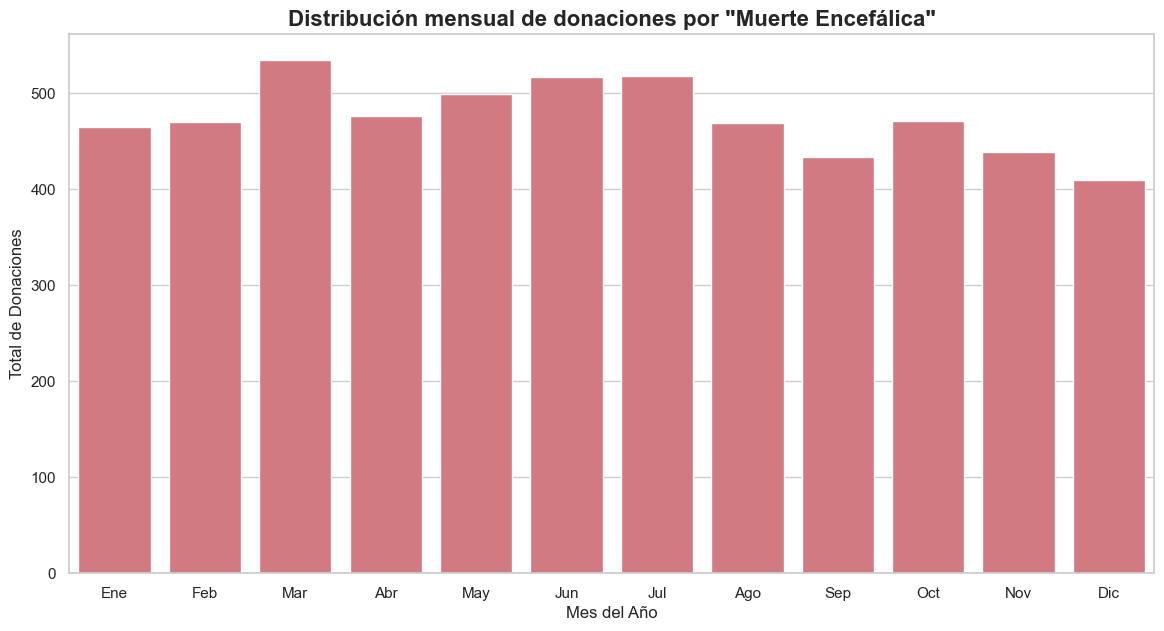

In [45]:
# Definir el tamaño de la figura
plt.figure(figsize=(14, 7))

# Crear la gráfica de conteo
ax = sns.countplot(
    data=df_muerte_encefalica,  # Usamos el DataFrame filtrado
    x='MES'                       # Eje X: la columna de mes
)

# --- Mejorar la fráfica ---
ax.set_title('Distribución mensual de donaciones por "Muerte Encefálica"', fontsize=16, weight='bold')
ax.set_xlabel('Mes del Año', fontsize=12)
ax.set_ylabel('Total de Donaciones', fontsize=12)

# Definir las etiquetas de texto para el eje X
meses_labels = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

# Aplica las etiquetas de texto
ax.set_xticklabels(meses_labels)

plt.show()

#### **Paso 3.3: Interpretación y conclusión de la Gráfica 3**

La gráfica de barras nos muestra el número total de donaciones provenientes de "Muerte Encefálica" para cada mes del año.

* **Hallazgo 1 (Pico principal):** Se observa un pico claro en el mes de **Marzo**, siendo este el mes con la mayor cantidad de donaciones de este tipo (superando las 500).

* **Hallazgo 2 (Meses de verano):** La pregunta sobre los meses de verano (Junio, Julio, Agosto) tiene una respuesta mixta. **Junio** presenta un pico notable (el segundo o tercero más alto del año), pero la tendencia **no se mantiene**, ya que las donaciones disminuyen en Julio y Agosto.

* **Hallazgo 3 (diciembre):** Respondiendo a la segunda parte de la pregunta, el mes de **Diciembre** no muestra un incremento. De hecho, es uno de los meses con el **menor** número de donaciones del año, junto con Diciembre.

**Respuesta a la pregunta 3:** La distribución de donaciones por "Muerte Encefálica" no es uniforme, con un pico significativo en Marzo. No se detecta un incremento sostenido durante los meses de verano (solo en Junio) y el mes de Diciembre es uno de los meses con menos donaciones de este tipo.
- - -

### Pregunta 4: Proporción Cadáver vs. Vivo en las top 10 entidades

**Pregunta textual:** "¿En las 10 entidades con mayor donación, ¿cuál es la proporción de donantes "Cadáver" vs. "Vivo"?"

**Mi plan:** 
* 1. Primero, identificar las "10 entidades con mayor donación". Haremos un conteo total por `ENTIDAD_FEDERATIVA` y seleccionaremos las 10 primeras. Guardaremos sus nombres en una lista.
* 2. Crearemos un nuevo DataFrame que contenga *solamente* las donaciones de esas 10 entidades. Usaremos el método `.isin()` para filtrar.
* 3. Graficar los datos. La pregunta pide "proporción". Un gráfico de barras normal mostraría el conteo total, pero un **gráfico de barras apilado al 100% (stacked bar chart)** es mucho mejor. Este tipo de gráfica muestra cómo se divide el 100% de cada entidad, permitiéndonos comparar la proporción visualmente.
- - -

#### **Paso 4.1: Identificar las top 10 entidades **

Usamos `value_counts()` y esta vez **excluimos** la categoría `'DESCONOCIDO'` *antes* de seleccionar el top 10. Usamos `.drop('DESCONOCIDO')` para quitar esa fila de nuestros conteos, asegurando que solo obtengamos las 10 entidades geográficas reales con más donaciones.

In [46]:
# Obtenemos los conteos de todas las entidades
conteo_entidades = df['ENTIDAD_FEDERATIVA'].value_counts()

# Quitamos la fila 'DESCONOCIDO' de nuestros conteos
conteo_entidades_filtrado = conteo_entidades.drop('DESCONOCIDO')

# Obtenemos las 10 más grandes del conteo filtrado
top_10_entidades = conteo_entidades_filtrado.nlargest(10)

print("Top 10 entidades (reales) con más donaciones:")
print(top_10_entidades)

# Creamos una lista solo con los nombres
top_10_entidades_lista = top_10_entidades.index.tolist()

Top 10 entidades (reales) con más donaciones:
ENTIDAD_FEDERATIVA
CIUDAD DE MEXICO    11992
JALISCO              6375
MEXICO               5973
AGUASCALIENTES       3328
NUEVO LEON           2509
PUEBLA               2258
GUANAJUATO           2165
COAHUILA             1889
QUERETARO            1561
VERACRUZ             1317
Name: count, dtype: int64


#### **Paso 4.2: Filtrar y ordenar el Dataframe**
Creamos el DataFrame `df_top10` usando nuestra nueva `top_10_entidades_lista`. Luego, convertimos la columna `ENTIDAD_FEDERATIVA` a un tipo "Categorical" (Categórico) para que Seaborn respete el orden de las barras en el eje Y.

In [47]:
# Usar .isin() para filtrar el DataFrame principal.
df_top10 = df[df['ENTIDAD_FEDERATIVA'].isin(top_10_entidades_lista)].copy()

# Convertir la columna a un tipo Categórico con un orden específico.
df_top10['ENTIDAD_FEDERATIVA'] = pd.Categorical(
    df_top10['ENTIDAD_FEDERATIVA'],
    categories=top_10_entidades_lista, # El orden que queremos.
    ordered=True                       # Le decimos que el orden importa.
)

print(f"DataFrame filtrado creado. Forma: {df_top10.shape}")

DataFrame filtrado creado. Forma: (39367, 28)


#### **Paso 4.3: Generar gráfica**

Se crea la gráfica con `sns.histplot()` y se realizan ajustes para evitar que la leyenda no se renderice bien.

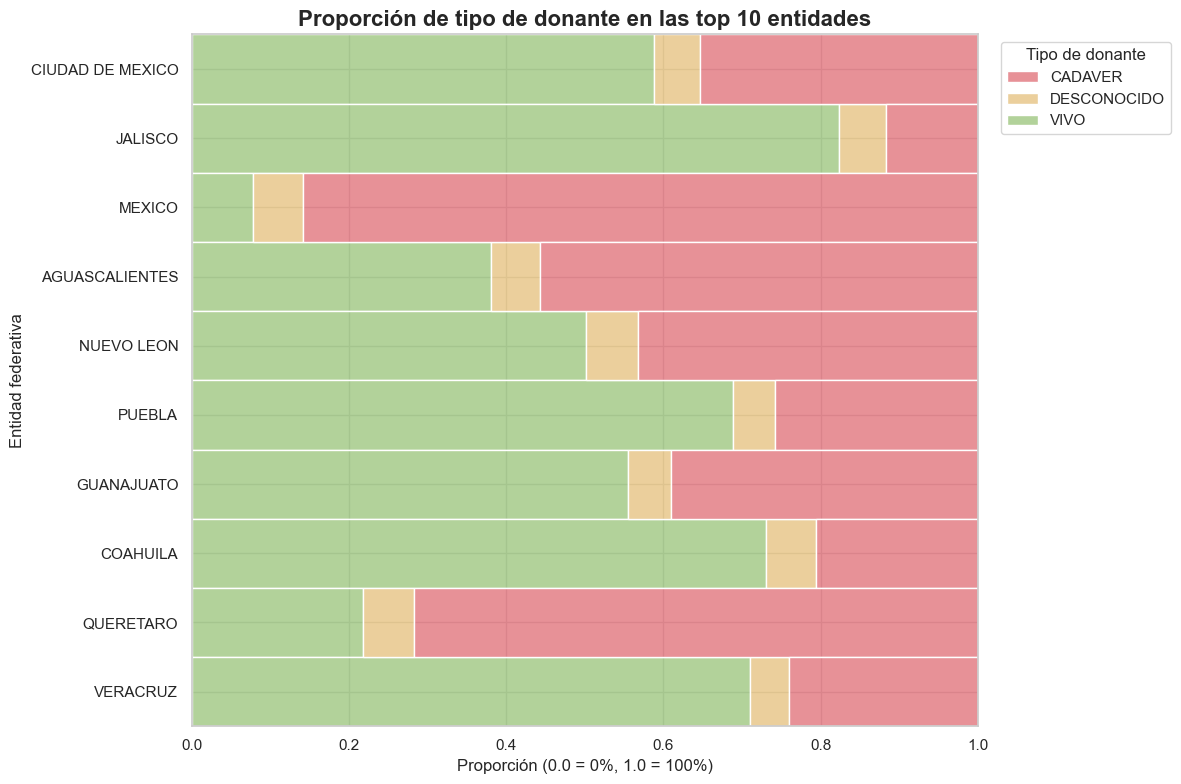

In [48]:
# Definir el tamaño de la figura.
plt.figure(figsize=(12, 8))

# Crear la gráfica y la asignamos a la variable 'ax'.
ax = sns.histplot(
    data=df_top10,
    y='ENTIDAD_FEDERATIVA',
    hue='TIPO_DONANTE',
    multiple="fill"
)

# --- Mejorar la gráfica ---
plt.title('Proporción de tipo de donante en las top 10 entidades', fontsize=16, weight='bold')
plt.xlabel('Proporción (0.0 = 0%, 1.0 = 100%)', fontsize=12)
plt.ylabel('Entidad federativa', fontsize=12)
sns.move_legend(ax, title='Tipo de donante', loc='upper left', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

#### **Paso 4.4: Interpretación y conclusión de la Gráfica 4**

El eje X de esta gráfica va de 0.0 (0%) a 1.0 (100%). Cada barra de color representa la proporción de ese tipo de donante para esa entidad.

* **Hallazgo 1 (diferencia clave):** La gráfica revela una diferencia fundamental en la *composición* de las donaciones entre las entidades. No todas siguen el mismo patrón.

* **Hallazgo 2 (dominio 'VIVO'):** La mayoría de las entidades top, como **'CIUDAD DE MEXICO'**, **'JALISCO'** y **'PUEBLA'**, tienen una proporción dominante de donantes de tipo **'VIVO'** (la barra verde), que representa más del 60% de sus casos.

* **Hallazgo 3 (dominio 'CADAVER'):** Tal como se observó, los estados de **'MEXICO'**, **'AGUASCALIENTES'** y **'QUERETARO'** rompen esta tendencia. En estas entidades, la proporción se invierte, y la mayoría de sus donaciones (más del 60-70%) provienen de donantes **'CADAVER'** (la barra roja).

* **Hallazgo 4 (datos 'DESCONOCIDO'):** La barra de 'DESCONOCIDO' (amarilla) se mantiene consistentemente pequeña en todas las entidades, lo que indica que la falta de este dato es un problema menor en las entidades con más registros.

**Respuesta a la pregunta 4:** En las 10 entidades con mayor donación, la proporción de tipo de donante varía significativamente. Mientras que entidades como 'CIUDAD DE MEXICO' y 'JALISCO' basan la mayoría de sus donaciones en donantes 'VIVO', otros estados clave como 'MEXICO' y 'QUERETARO' tienen una composición opuesta, con una mayoría de donantes 'CADAVER'.
- - -

### Pregunta 5: Últimos cinco lugares de donación

**Pregunta textual:** "¿Cuáles entidades son los últimos cinco lugares de donación de órganos en el país?"

**Mi plan:** 
* 1. Usar `value_counts()` en la columna `ENTIDAD_FEDERATIVA` para obtener el conteo de todas. 
* 2. Filtrar la categoría `'DESCONOCIDO'` para que no aparezca en nuestro ranking. 
* 3. Usar el método `.nsmallest(5)` para obtener las 5 entidades con los conteos más bajos.
* 4. Usar `sns.barplot()` para visualizar estas 5 entidades.
- - -

#### **Paso 5.1: Calcular las 5 Entidades con Menos Donaciones**

Primero, contamos todas las entidades. Luego, usamos `.drop('DESCONOCIDO')` para quitar esa fila y asegurarnos de que estamos clasificando entidades geográficas reales. Finalmente, usamos `.nsmallest(5)` para obtener los 5 últimos lugares.

In [49]:
# Obtener los conteos de todas las entidades.
conteo_entidades = df['ENTIDAD_FEDERATIVA'].value_counts()

# Quitar la fila 'DESCONOCIDO' de nuestros conteos.
conteo_entidades_filtrado = conteo_entidades.drop('DESCONOCIDO')

# Usar .nsmallest(5) para obtener los 5 valores más bajos.
bottom_5_entidades = conteo_entidades_filtrado.nsmallest(5)

print(bottom_5_entidades)

ENTIDAD_FEDERATIVA
CAMPECHE         4
NAYARIT         24
QUINTANA ROO    45
OAXACA          60
COLIMA          65
Name: count, dtype: int64


#### **Paso 5.2: Generar la Gráfica**

Ahora, creamos un gráfico de barras simple para visualizar estos 5 últimos lugares. Usamos `bottom_5_entidades.index` para el eje X (los nombres) y `bottom_5_entidades.values` para el eje Y (los conteos).

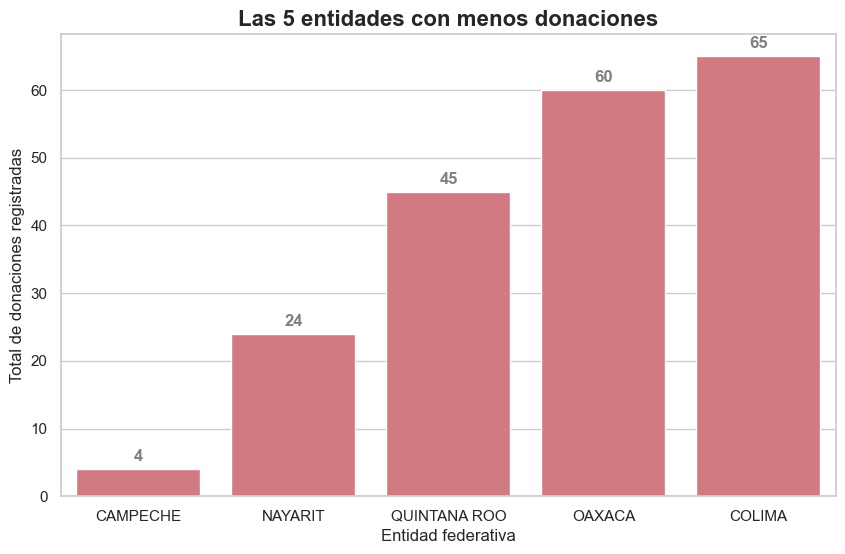

In [50]:
# Definir el tamaño de la figura.
plt.figure(figsize=(10, 6))

# Crear la gráfica de barras.
# Pasar 'x' e 'y' directamente.
ax = sns.barplot(
    x=bottom_5_entidades.index,    # Eje X: Los nombres de las 5 entidades.
    y=bottom_5_entidades.values    # Eje Y: El número de donaciones.
)

# --- Mejorar la gráfica ---
ax.set_title('Las 5 entidades con menos donaciones', fontsize=16, weight='bold')
ax.set_xlabel('Entidad federativa', fontsize=12)
ax.set_ylabel('Total de donaciones registradas', fontsize=12)

# Ciclo 'for' que dibuja el número (conteo) encima de cada barra.
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'),  # Quitar decimales.
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                color='gray',
                weight='bold')

plt.show()

#### Paso 5.3: Interpretación y conclusión de la gráfica 5

* **Hallazgo:** El gráfico de barras muestra claramente las 5 entidades con el menor número de registros de donación en el dataset.

**Respuesta a la pregunta 5:** Las 5 entidades con menor actividad de donación registrada en el país son **CAMPECHE** (con solo 4 registros), **NAYARIT** (24), **QUINTANA ROO** (45), **OAXACA** (60) y **COLIMA** (65).
- - -

### Pregunta 6: Ranking de las principales instituciones

**Pregunta textual:** "¿Cuál es el ranking de las principales instituciones (IMSS, ISSSTE, etc.) según el número total de donaciones registradas?"

**Mi plan:** 
* 1. Usar `value_counts()` en la columna `INSTITUCION`.
* 2. Filtrar la categoría `'DESCONOCIDO'`  para obtener un ranking de instituciones reales. 
* 3. Usar el método `.nlargest(10)` para obtener las 10 instituciones con los conteos más altos. 
* 4. Usar `sns.barplot()` para visualizar este ranking.
- - -

#### **Paso 6.1: Calcular las 10 instituciones con más donaciones**

Contamos todas las instituciones, filtramos la categoría 'DESCONOCIDO' y seleccionamos las 10 primeras con `.nlargest(10)`.

In [51]:
# Obtener los conteso de todas las institucioes. 
conteo_instituciones = df['INSTITUCION'].value_counts()

# Quitar la fila 'DESCONOCIDO' de nuestros conteos.
conteo_instituciones_filtrado = conteo_instituciones.drop('DESCONOCIDO')

# Usar .nlargest(10) para obtener los 10 valores más altos.
top_10_instituciones = conteo_instituciones_filtrado.nlargest(10)

print("Las 10 instituciones con más donaciones son:")
print(top_10_instituciones)

Las 10 instituciones con más donaciones son:
INSTITUCION
IMSS       20430
SSE        13293
PRIVADO     7750
SSA         3258
ISSSTE      1251
SEDENA       402
PEMEX        183
SEMAR         38
SNTE          23
Name: count, dtype: int64


#### **Paso 6.2: Generar la gráfica**

Creamos un gráfico de barras para visualizar este top 10. Para que lea mejor, se pondrán las barras en horizontal, colocando las instituciones en el eje y y los conteos en el eje X.

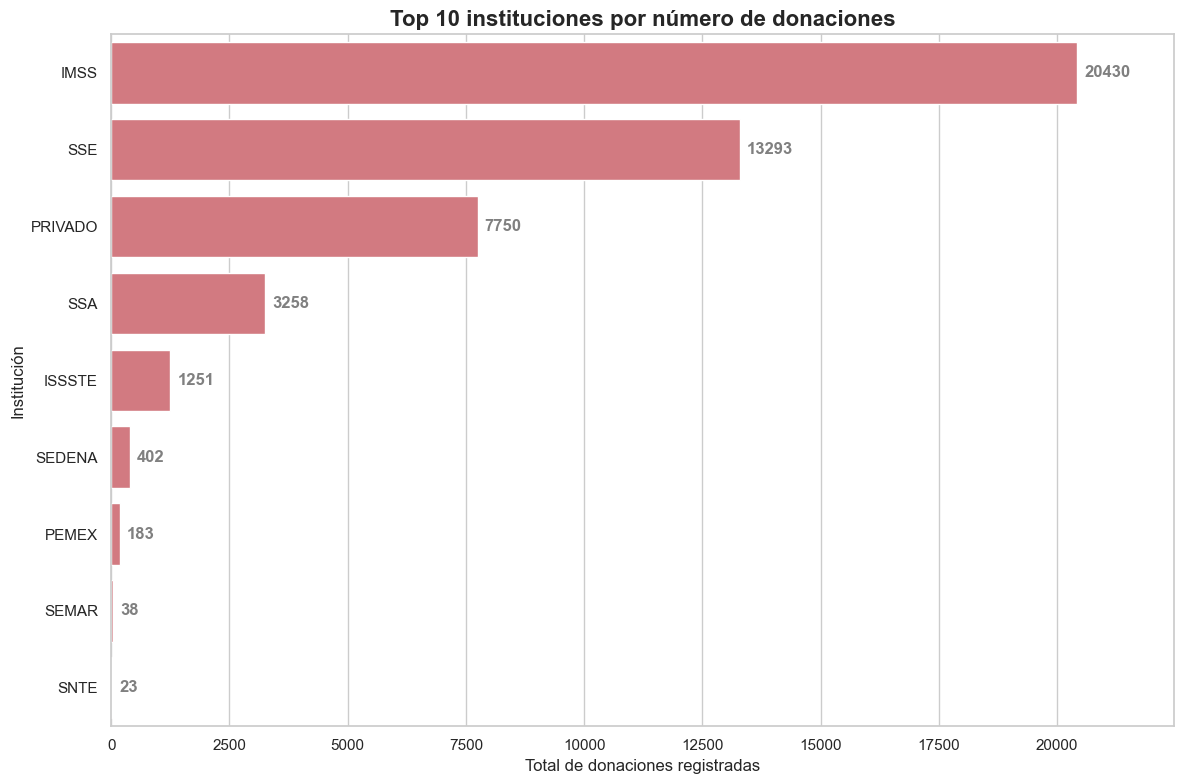

In [52]:
# Definir el tamaño de la figura.
plt.figure(figsize=(12, 8))

# Creamos la gráfcia de barras horizontal.
ax = sns.barplot(
    x=top_10_instituciones.values,
    y=top_10_instituciones.index
)

# --- Mejorar la grafica ---
ax.set_title('Top 10 instituciones por número de donaciones', fontsize=16, weight='bold')
ax.set_xlabel('Total de donaciones registradas', fontsize=12)
ax.set_ylabel('Institución')

# Ciclo 'for' que dibuja el número (conteo) al lado de cada barra.
for p in ax.patches:
    ax. annotate(format(p.get_width(), '.0f'),   
                (p.get_width() + 0.5, p.get_y() + p.get_height() / 2), 
                ha='left',   # Alinear a la izquierda del punto.
                va='center', # Centrar verticalmente.
                xytext=(5, 0), # 5 puntos de separación.
                textcoords='offset points',
                color='gray',
                weight='bold')
    
# Ajustar el límite derecho del eje X para dar espacio a los números.
plt.xlim(0, top_10_instituciones.max() * 1.1)

plt.tight_layout()
plt.show()

#### Paso 6.3: Interpretación y conclusión de la gráfica 6

* **Hallazgo 1:** El gráfico de barras muestra un ranking claro. La institución con la mayor cantidad de donaciones registradas es, por un amplio margen, el **IMSS**, con **20,430** casos.

* **Hallazgo 2:** La **SSE** (Secretaría de Salud) ocupa el segundo lugar con **13,293** registros, seguida por **PRIVADO** con **7,750**.

* **Hallazgo 3:** Se observa una diferencia muy grande entre las 3 primeras instituciones y el resto. Después de 'PRIVADO', el número de donaciones cae bruscamente a **3,258** para 'SSA' y **1,251** para 'ISSSTE'. Las demás instituciones del top 10 tienen menos de 500 registros cada una.

**Respuesta a la pregunta 6:** El ranking de las principales instituciones está liderado por el IMSS (20,430 donaciones) y la SSE (13,293). Estas dos instituciones, junto con el sector PRIVADO (7,750), concentran la gran mayoría de las donaciones registradas en el país.
- - -

### Pregunta 7: Edad promedio en IMSS vs. Privado

**Pregunta textual:** "¿Cuál es la edad promedio de los donantes que provienen de la institución IMSS en comparación con los donantes de la institución privada?"

**Mi plan:** 
* 1. Primero, filtrar nuestro DataFrame `df` para crear uno nuevo que solo contenga las filas donde la `INSTITUCION` es `'IMSS'` o `'PRIVADO'`.
* 2. Calcular el promedio (media) de la columna `EDAD_ANIOS` para cada una de esas dos instituciones. 
* 3. Usar `sns.barplot()` para crear una gráfica simple que compare los dos promedios.
- - -

#### **Paso 7.1: Filtrar el DataFrame por 'IMSS' y 'PRIVADO'**

Creamos una lista con las dos instituciones que nos interesan. Luego, usamos el método `.isin()` para seleccionar solo las filas del DataFrame `df` que pertenezcan a una de esas dos.

In [53]:
# Definir la lista de instituciones que queremos comparar.
instituciones_comparar = ['IMSS', 'PRIVADO']

# Filtrar el DataFrame.
df_imss_privado = df[df['INSTITUCION'].isin(instituciones_comparar)].copy()

print(f"DataFrame filtrado creado. Total de registros IMSS/PRIVADO: {len(df_imss_privado)}")

DataFrame filtrado creado. Total de registros IMSS/PRIVADO: 28180


#### **Paso 7.2: Calcular los Promedios de Edad**

Usamos `.groupby()` para agrupar por `INSTITUCION`, seleccionamos la columna `EDAD_ANIOS` y aplicamos el método `.mean()` (media/promedio).

In [54]:
# Agrupamos por institucion y calculamos la media de edad
promedio_edad = df_imss_privado.groupby('INSTITUCION')['EDAD_ANIOS'].mean()

print("Edad promedio por institución:")
print(promedio_edad)

Edad promedio por institución:
INSTITUCION
IMSS       38.663045
PRIVADO    35.351484
Name: EDAD_ANIOS, dtype: float64


#### **Paso 7.3: Generar la Gráfica**

Ahora, creamos un gráfico de barras simple usando nuestro DataFrame filtrado `df_imss_privado`. Le pasamos `'INSTITUCION'` al eje X y `'EDAD_ANIOS'` al eje Y. Seaborn se encargará de calcular y mostrar el promedio de edad para cada una.

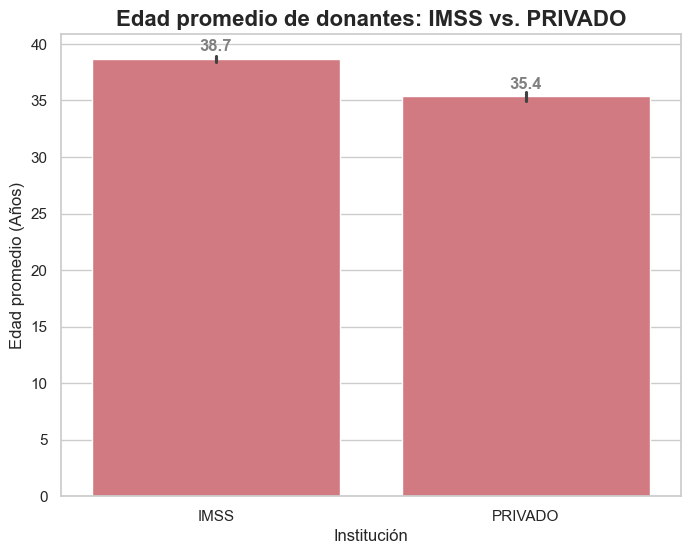

In [55]:
# Definir el tamaño de la figura.
plt.figure(figsize=(8, 6))

# Crear la gráfica de barras.
# Seaborn calcula automáticamente el promedio de 'EDAD_ANIOS'.
ax = sns.barplot(
    data=df_imss_privado,
    x='INSTITUCION',    # Eje X: Las dos categorías.
    y='EDAD_ANIOS'      # Eje Y: La variable numérica a promediar.
)

# --- Mejorar la gráfica ---
ax.set_title('Edad promedio de donantes: IMSS vs. PRIVADO', fontsize=16, weight='bold')
ax.set_xlabel('Institución', fontsize=12)
ax.set_ylabel('Edad promedio (Años)', fontsize=12)

# Ciclo 'for' que dibuja el número (promedio) encima de cada barra.
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.1f'),  
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                color='gray',
                weight='bold')

plt.show()

#### **Paso 7.4: Interpretación y Conclusión de la Gráfica 7**

* **Hallazgo:** El gráfico de barras compara directamente la edad promedio de los donantes de las dos instituciones con más registros. Se observa una ligera diferencia.

**Respuesta a la pregunta 7:** La edad promedio de los donantes en la institución **IMSS** es de **38.7 años**, mientras que en la institución **PRIVADO** es ligeramente menor, con **35.4 años**. Ambas instituciones atienden a una población de donantes predominantemente adulta-joven, con una diferencia de aproximadamente 3 años entre ellas.
- - -

### Pregunta 8: Total de donaciones en la región sur

**Pregunta textual:** "¿Cuál es el número total de donaciones registradas en la región sur del país?"

**Mi plan:**
* 1. Definir una lista que contenga los nombres de los estados que consideramos "región sur".
* 2. Usar el método .isin()para filtrar nuestro DataFramedf y crear uno nuevo (df_sur) que solo contenga las filas de esos estados.
* 3. Obtener el número total de donaciones para esta región (simplemente contando las filas del nuevo DataFrame) y también generar un gráfico de barras para ver el desglose por cada estado del sur.

#### **Paso 8.1: Definir la región sur y filtrar**

Primero, creamos una lista de Python con los estados del sur de México. Luego, usamos `.isin()` para seleccionar solo las filas del DataFrame principal que coincidan con esta lista.

In [56]:
# Definir la lista de estados para la región sur.
region_sur = [
    'CHIAPAS', 
    'GUERRERO', 
    'OAXACA', 
    'TABASCO', 
    'VERACRUZ', 
    'CAMPECHE', 
    'QUINTANA ROO', 
    'YUCATAN'
]

# Filtrar el DataFrame principal.
df_sur = df[df['ENTIDAD_FEDERATIVA'].isin(region_sur)].copy()

# Usar len() para contar el número total de filas (donaciones)
print(f"El número total de donaciones en la región sur es: {len(df_sur)}")

El número total de donaciones en la región sur es: 2652


#### **Paso 8.2: Generar la gráfica (desglose por estado)**

Para entender mejor de dónde vienen esas donaciones, creamos un gráfico de barras que muestre el conteo para cada estado dentro de la región sur.

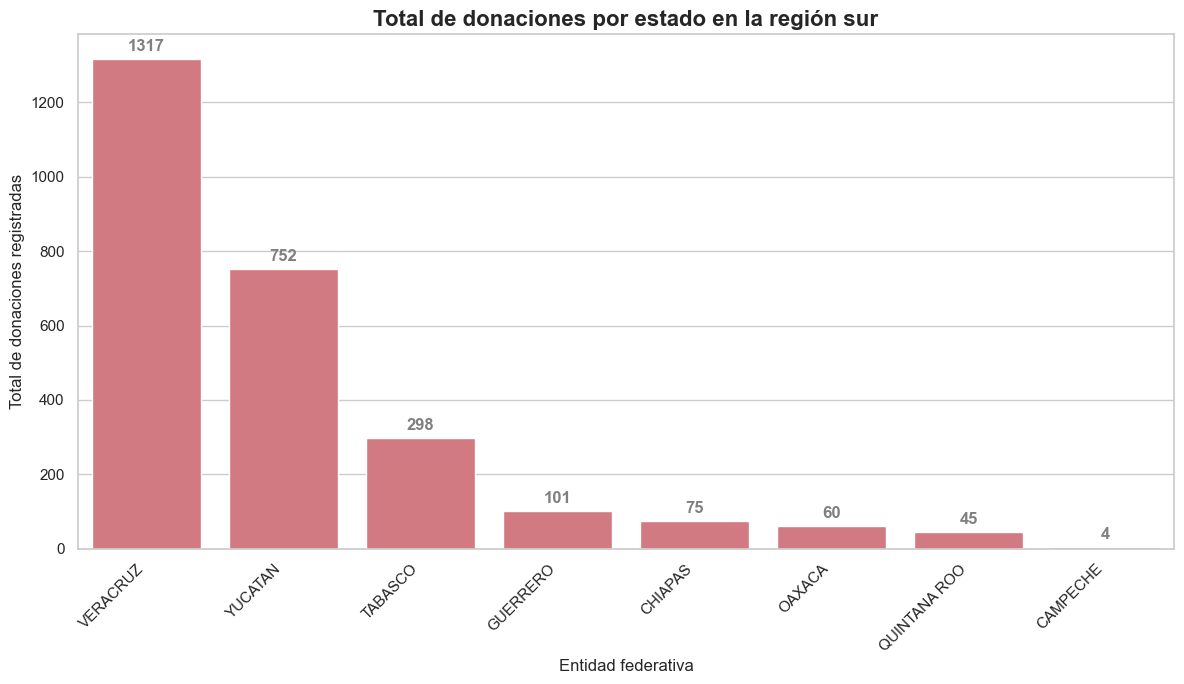

In [57]:
# Contar cuántas donaciones hay por cada estado en el sur.
conteo_sur = df_sur['ENTIDAD_FEDERATIVA'].value_counts()

# Definir el tamaño de la figura.
plt.figure(figsize=(12, 7))

# Crear la gráfica de barras.
ax = sns.barplot(
    x=conteo_sur.index,
    y=conteo_sur.values
)

# --- Mejorar la gráfica ---
ax.set_title('Total de donaciones por estado en la región sur', fontsize=16, weight='bold')
ax.set_xlabel('Entidad federativa', fontsize=12)
ax.set_ylabel('Total de donaciones registradas', fontsize=12)

# Rotar las etiquetas del eje X si se enciman.
plt.xticks(rotation=45, ha='right')

# Ciclo 'for' que dibuja el número (conteo) encima de cada barra.
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'),
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                color='gray',
                weight='bold')

plt.tight_layout()
plt.show()

#### Paso 8.3: Interpretación y Conclusión de la Gráfica 8

* **Hallazgo 1:** Sumando los valores de todas las barras, el número total de donaciones registradas en la región sur es de **2,652**.

* **Hallazgo 2:** El gráfico de barras muestra un desglose muy desigual dentro de la región. **VERACRUZ** es, por un margen enorme, el estado con más donaciones (1,317), seguido por **YUCATAN** (752) y **TABASCO** (298).

* **Hallazgo 3:** Los estados de **OAXACA** (60), **QUINTANA ROO** (45) y **CAMPECHE** (4) muestran la actividad de donación más baja de la región.

**Respuesta a la pregunta 8:** El número total de donaciones registradas en la región sur es de **2,652**. Dentro de esta región, la actividad está fuertemente concentrada en VERACRUZ, que representa casi la mitad de todas las donaciones del sur.
- - -

### Pregunta 9: Total de donaciones en la región norte

**Pregunta textual:** "¿Cuál es el número total de donaciones registradas en la región norte del país?"

**Mi plan:** 
* 1. Definir una lista con los estados que consideramos "región norte".
* 2. Usar `.isin()` para filtrar el DataFrame `df` y crear `df_norte`.
* 3. Obtener el número total (contando las filas) y generar un gráfico de barras para el desglose.

#### **Paso 9.1: Definir la Región Norte y Filtrar**

Creamos una lista de Python con los estados del norte de México y filtramos el DataFrame principal.

In [58]:
# Definir la lista de estados para la región norte.
region_norte = [
    'BAJA CALIFORNIA',
    'BAJA CALIFORNIA SUR',
    'COAHUILA',
    'CHIHUAHUA',
    'DURANGO',
    'NUEVO LEON',
    'SINALOA',
    'SONORA',
    'TAMAULIPAS',
    'ZACATECAS' 
]

# Filtrar el DataFrame principal.
df_norte = df[df['ENTIDAD_FEDERATIVA'].isin(region_norte)].copy()

# Usar len() para contar el número total de filas (donaciones). 
print(f"El número total de donaciones en la región norte es: {len(df_norte)}")

El número total de donaciones en la región norte es: 8126


#### **Paso 9.2: Generar la Gráfica (Desglose por Estado)**

Creamos un gráfico de barras que muestre el conteo para cada estado dentro de la región norte.

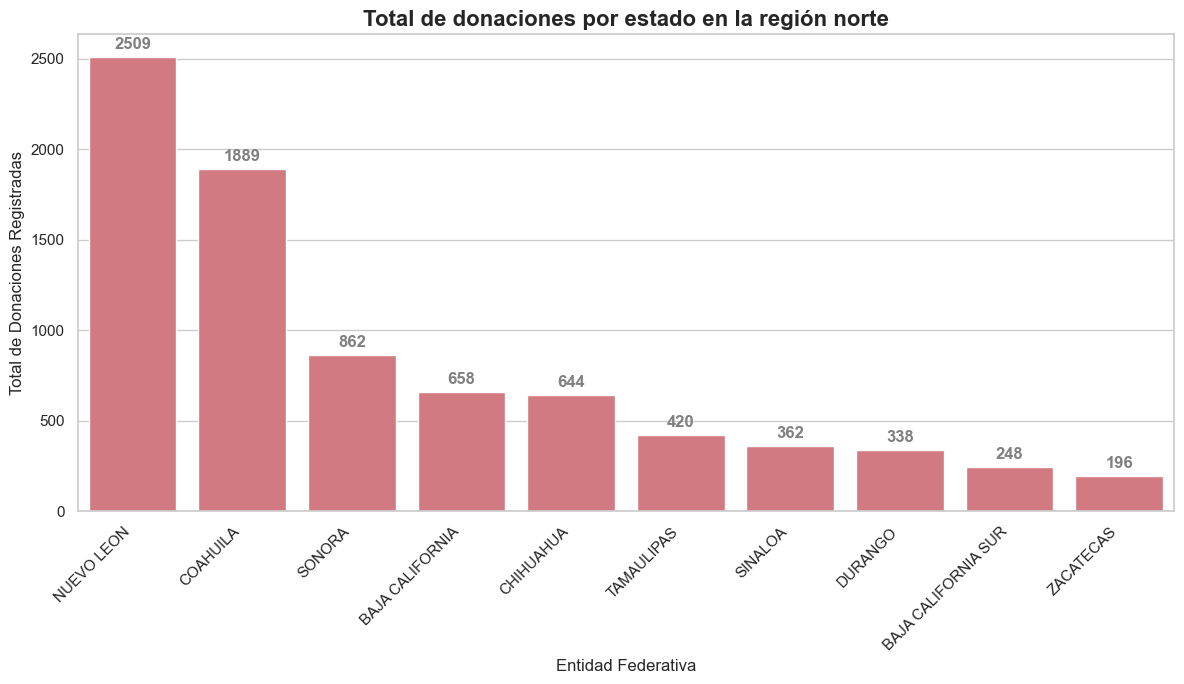

In [59]:
# Contar cuántas donaciones hay por cada estado en el norte.
conteo_norte = df_norte['ENTIDAD_FEDERATIVA'].value_counts()

# Definir el tamaño de la figura.
plt.figure(figsize=(12, 7))

# Crear la gráfica de barras.
ax = sns.barplot(
    x=conteo_norte.index,
    y=conteo_norte.values
)

# --- Mejorar la gráfica ---
ax.set_title('Total de donaciones por estado en la región norte', fontsize=16, weight='bold')
ax.set_xlabel('Entidad Federativa', fontsize=12)
ax.set_ylabel('Total de Donaciones Registradas', fontsize=12)

# Rotar las etiquetas del eje X para que no se encimen.
plt.xticks(rotation=45, ha='right')

# Ciclo 'for' que dibuja el número (conteo) encima de cada barra.
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'),
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                color='gray',
                weight='bold')

plt.tight_layout()
plt.show()

#### **Paso 9.3: Interpretación y Conclusión de la Gráfica 9**

* **Hallazgo 1:** Sumando los valores de todas las barras, el número total de donaciones registradas en la región norte es de **8,126**. Este número es significativamente mayor que el de la región sur (2,652).

* **Hallazgo 2:** La actividad en el norte está claramente liderada por **NUEVO LEON** (2,509 donaciones) y **COAHUILA** (1,889). Estos dos estados por sí solos representan más del 50% de todas las donaciones de la región.

* **Hallazgo 3:** El resto de los estados del norte, como **SONORA** (862), **BAJA CALIFORNIA** (658) y **CHIHUAHUA** (644), forman un segundo grupo con una actividad considerable, a diferencia del sur donde la actividad caía drásticamente después de los dos primeros estados.

**Respuesta a la pregunta 9:** El número total de donaciones registradas en la región norte es de **8,126**. A diferencia de la región sur, la actividad en el norte no solo es mayor, sino que está distribuida entre varios estados clave, con un fuerte liderazgo de NUEVO LEON (2,509) y COAHUILA (1,889).
- - -

### Pregunta 10: Promedio de edad de todas las donaciones

**Pregunta textual:** "¿Cuál es el promedio de la edad de todas las donaciones en el país?"

**Mi plan:** 
* 1. (Paso 10.1) Calcular el promedio (media) de la columna EDAD_ANIOSpara todo el DataFramedf.
* 2. (Paso 10.2) Generar una gráfica para ver *cómo se distribuyen* todas las edades. Un promedio puede ser engañoso si hay muchos niños y muchos ancianos (se promedian al centro). Un **histograma (sns.histplot)** es la gráfica correcta para ver la "forma" de los datos.
- - -

#### **Paso 10.1: Calcular el Promedio de Edad General**

Usamos el método `.mean()` en la columna `EDAD_ANIOS` de todo el DataFrame para obtener el promedio nacional. Para calcular un promedio *real* de las edades de donantes conocidos, debemos filtrar estos '0's.

In [60]:
# Filtrar el DataFrame para excluir las edades de 0.
df_edades_validas = df[df['EDAD_ANIOS'] > 0].copy()

# Calculamos la media solo de las edades válidas.
promedio_edad_nacional = df_edades_validas['EDAD_ANIOS'].mean()

print(f"Total de donaciones con edad válida (mayor a 0): {len(df_edades_validas)}")
print(f"El promedio de edad de donantes con edad válida es: {promedio_edad_nacional}")

Total de donaciones con edad válida (mayor a 0): 46337
El promedio de edad de donantes con edad válida es: 41.65235125277856


#### **Paso 10.2: Generar la Gráfica (Histograma de Edades)**

Usamos `sns.histplot`en la columna `EDAD_ANIOS`. El argumento `kde=True` dibuja una línea suave sobre las barras (llamada "Estimación de Densidad de Kernel") que nos ayuda a ver la forma de la distribución más fácilmente.

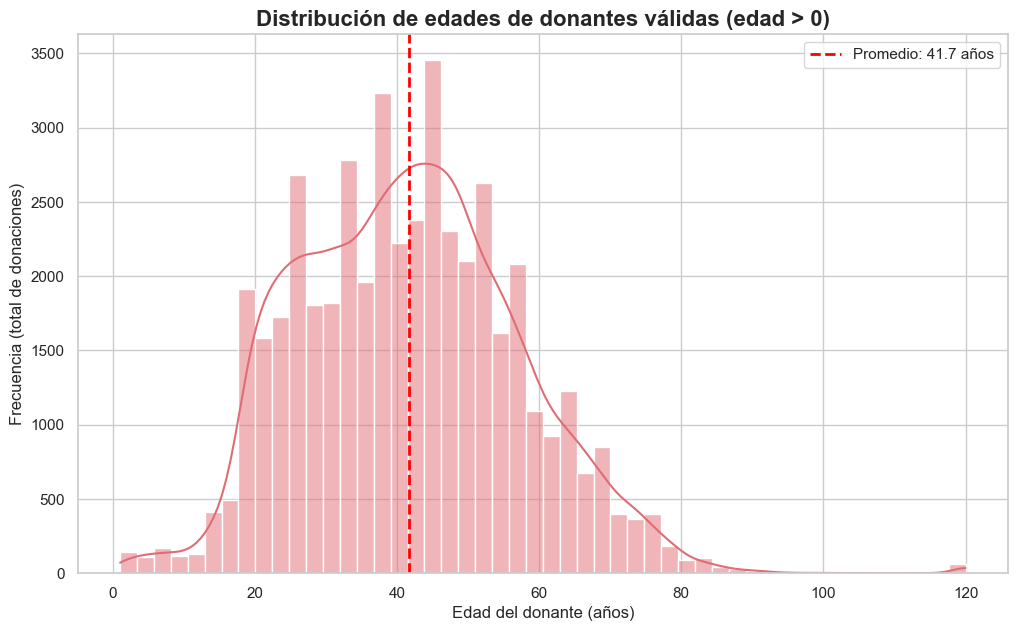

In [61]:
## Definir el tamaño de la figura.
plt.figure(figsize=(12, 7))

# Crear el histograma usando el DataFrame filtrado.
ax = sns.histplot(
    data=df_edades_validas,
    x='EDAD_ANIOS',
    kde=True,
    bins=50
)

# --- Mejorar la gráfica ---
ax.set_title('Distribución de edades de donantes válidas (edad > 0)', fontsize=16, weight='bold')
ax.set_xlabel('Edad del donante (años)', fontsize=12)
ax.set_ylabel('Frecuencia (total de donaciones)', fontsize=12)

# Dibujar la línea vertical con el promedio.
plt.axvline(
    x=promedio_edad_nacional,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Promedio: {promedio_edad_nacional:.1f} años'
)

plt.legend()
plt.show()

#### Paso 10.3: Interpretación y Conclusión de la Gráfica 10

* **Hallazgo 1:** Después de filtrar los valores '0' (que representaban datos inválidos de la limpieza), el histograma muestra la distribución real de las edades de los donantes. El nuevo promedio de edad, y más preciso, es de **41.7 años** (marcado por la línea roja).

* **Hallazgo 2:** La distribución ahora es mucho más clara. Se observa que la mayor concentración de donantes se encuentra entre los **20 y 55 años**. La forma de la gráfica muestra un pico claro alrededor de los 40-45 años, lo cual está muy cerca del promedio.

* **Hallazgo 3:** Se confirma que la gran mayoría de los donantes son adultos, y la cantidad de donaciones disminuye significativamente después de los 60 años.

**Respuesta a la pregunta 10:** El promedio de edad de los donantes con un registro válido (mayor a 0) es de **41.7 años**. La distribución muestra que la mayoría de los donantes son adultos, con una mayor concentración de donaciones ocurriendo entre los 20 y 55 años.
- - -

## **Parte 2:** Validando las 3 hipótesis.
- - -

**Hipótesis textual 1:** "Se hipotetiza que el éxito de una donación multi-órgano (donación de 3 o más órganos/tejidos) está significativamente correlacionado con una edad menor a 50 años y el factor institución de salud (IMSS, ISSTE y PRIVADO)."

**Mi plan:**
* 1. Crear una nueva columna ES_MULTIORGANO. La definiremos como `1` (Sí) si `TOTAL_ORGANOS` es 3 o más, y `0` (No) si es menos de 3.
* 2. Filtrar nuestro DataFrame para quedarnos *solamente* con las 3 instituciones que menciona la hipótesis (IMSS, ISSSTE, PRIVADO) y crear dos grupos de edad ('Menor a 50' y '50 o más').
* 3. Generar la gráfica. Usaremos un `sns.barplot()` agrupado. Esta gráfica es perfecta porque al pedirle el *promedio* (media) de nuestra columna `ES_MULTIORGANO` (que solo tiene 1s y 0s), el resultado que nos da es la **tasa** o **porcentaje** de éxito.
- - -

#### **Paso H1.1: Crear la columna 'ES_MULTIORGANO'**

Definimos "Donación Multi-Órgano" como 3 o más órganos, tal como dice la hipótesis. La expresión `df['TOTAL_ORGANOS'] >= 3` crea una columna de `True/False`. Usamos `.astype(int)` para convertir `True` en `1` (Sí) y `False` en `0` (No).

In [62]:
# (df['TOTAL_ORGANOS'] >= 3) crear una columna True/False.
df['ES_MULTIORGANO'] = (df['TOTAL_ORGANOS'] >= 3).astype(int)

# Usar value_counts() para ver cuántos 'Sí' (1) y 'No' (0) tenemos.
print("Conteo (1 = Sí es Multi-Órgano, 0 = No lo es):")
print(df['ES_MULTIORGANO'].value_counts())

Conteo (1 = Sí es Multi-Órgano, 0 = No lo es):
ES_MULTIORGANO
0    43972
1     5627
Name: count, dtype: int64


#### **Paso H1.2: Filtrar datos para la hipótesis**

Ahora, creamos un nuevo DataFrame `df_h1` que contenga solo las filas relevantes: 1. Institución sea 'IMSS', 'ISSSTE' o 'PRIVADO'. 2. La edad sea válida (mayor a 0, para excluir los datos que limpiamos).

También creamos la columna `RANGO_EDAD_H1` para agrupar por 'Menor a 50' y '50 o más'.

In [63]:
# Definir las instituciones que nos interesan.
instituciones_h1 = ['IMSS', 'ISSSTE', 'PRIVADO']

# Filtrar el DataFrame.
df_h1 = df[df['INSTITUCION'].isin(instituciones_h1)].copy()

# Filtrar filas donde la edad sea 0 (datos de limpieza).
df_h1 = df_h1[df_h1['EDAD_ANIOS'] > 0]

# Crear los rangos de edad (Menor de 50, 50 o más).
# Cortar en 0, 49, 120 (para que 49 caiga en 'Menor a 50').
bins_h1 = [0, 49, 120] 
labels_h1 = ['Menor a 50', '50 o más']
df_h1['RANGO_EDAD_H1'] = pd.cut(df_h1['EDAD_ANIOS'], 
                                bins=bins_h1, 
                                labels=labels_h1, 
                                right=True)

print(f"Forma: {df_h1.shape}")

Forma: (27461, 30)


#### **Paso H1.3: Generar la gráfica de tasa de éxito**

Generamos un gráfico de barras agrupado. El eje Y mostrará la "Tasa de Donación Multi-Órgano". Esto es el promedio de la columna `ES_MULTIORGANO`, que es lo mismo que el porcentaje de éxito.

Para que el eje Y se muestre como porcentaje, importamos PercentFormatter de matplotlib.

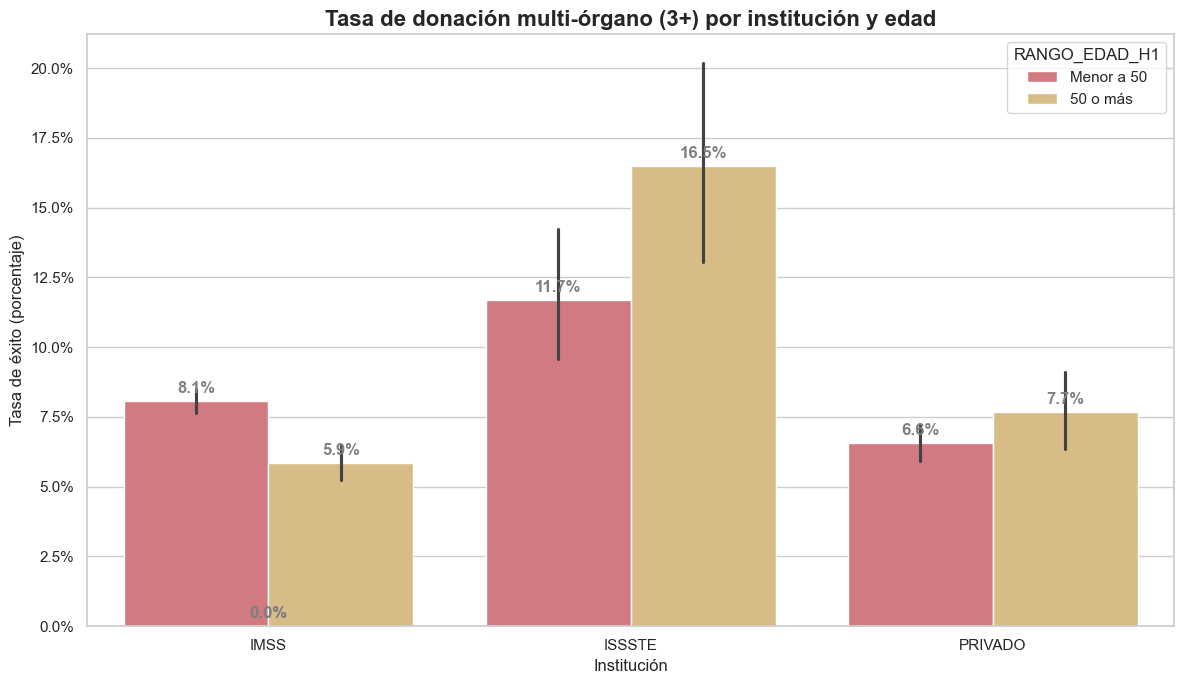

In [69]:
# Importar la función para formatear el eje como porcentaje.
from matplotlib.ticker import PercentFormatter

# Definir el tamaño de la figura.
plt.figure(figsize=(12, 7))

# Crear un barplot agrupado.
ax = sns.barplot(
    data=df_h1,
    x='INSTITUCION',      # Eje X: Las 3 instituciones.
    y='ES_MULTIORGANO',   # Eje Y: El promedio (tasa) de éxito.
    hue='RANGO_EDAD_H1',  # Agrupador: Los 2 grupos de edad.
    order=instituciones_h1 # Asegurar el orden IMSS, ISSSTE, PRIVADO.
)

# --- Mejorar la gráfica ---
ax.set_title('Tasa de donación multi-órgano (3+) por institución y edad', fontsize=16, weight='bold')
ax.set_xlabel('Institución', fontsize=12)
ax.set_ylabel('Tasa de éxito (porcentaje)', fontsize=12)

# Aplicar el formateador de porcentaje al eje Y.
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

# Ciclo 'for' que dibuja el porcentaje encima de cada barra.
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.1%'),  
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                color='gray',
                weight='bold')

plt.tight_layout()
plt.show()

#### **Paso H1.4: Interpretación y Conclusión de la Hipótesis 1**

* **Hipótesis:** "El éxito... está correlacionado con una edad menor a 50 años y el factor institución..."

* **Hallazgo 1 (factor edad):** Los datos **contradicen parcialmente** la hipótesis sobre la edad. Si bien en el **IMSS** la tasa de éxito es mayor en 'Menores a 50' (8.1% vs 5.8%), en **ISSSTE** y **PRIVADO** ocurre lo opuesto: la tasa de éxito es *mayor* en el grupo de '50 o más' (16.5% vs 11.7% en ISSSTE, y 7.7% vs 6.8% en PRIVADO).

* **Hallazgo 2 (factor institución):** La hipótesis **sí se comprueba** para el factor institución. Claramente hay una correlación, ya que las tasas de éxito son muy diferentes. El **ISSSTE** destaca con la tasa de éxito de donación multi-órgano más alta en general (llegando al 16.5% en su grupo de 50+), mientras que IMSS y PRIVADO tienen tasas más bajas, que rondan entre el 5% y 8%.

**Respuesta a la hipótesis 1:** La hipótesis es **VALIDADA PARCIALMENTE**. Se valida que la **institución** es un factor correlacionado (con el ISSSTE mostrando la tasa más alta). Sin embargo, la hipótesis sobre la edad es **RECHAZADA**, ya que en 2 de las 3 instituciones principales, la tasa de éxito de donación multi-órgano es de hecho *mayor* en donantes de 50 años o más.
- - -

### Hipótesis 2: Muerte Encefálica vs. Paro Cardiorrespiratorio

**Hipótesis textual:** "Se hipotetiza que la muerte encefálica como causa de donación presenta una tasa promedio de órganos procurados por evento más alta que el paro cardiorrespiratorio, independientemente de la edad del donante."

**Mi plan:**
* 1. Filtrar el DataFrame principal `df` para crear uno nuevo `df_h2` que solo contenga las dos causas de muerte a comparar: `MUERTE ENCEFÁLICA` y `PARO CARDIORESPIRATORIO`.
* 2. Usar la columna RANGO_EDAD que creamos en la Pregunta 1 para hacer la comparación "independientemente de la edad".
* 3. Generar un `sns.barplot()` agrupado. Pondremos la `EDAD` en el eje X y el `TOTAL_ORGANOS` en el eje Y. Usaremos `hue='MUERTE'` para ver las dos barras (Encefálica vs. Paro) una al lado de la otra en cada rango de edad.
- - -

#### **Paso H2.1: Filtrar el DataFrame por causa de muerte**

Creamos una lista con las dos causas de muerte que nos interesan. Luego, usamos `.isin()` para seleccionar solo las filas del DataFramedf que pertenezcan a una de esas dos.

In [65]:
# Definir la lista de causas de muerte a comparar.
causas_muerte_h2 = ['MUERTE ENCEFÁLICA', 'PARO CARDIORESPIRATORIO']

# Filtrar el DataFrame.
df_h2 = df[df['MUERTE'].isin(causas_muerte_h2)].copy()

print(f"DataFrame para Hipótesis 2 creado. Forma: {df_h2.shape}")

DataFrame para Hipótesis 2 creado. Forma: (20855, 29)


#### **Paso H2.2: Generar la Gráfica de Comparación**

Creamos el gráfico de barras agrupado. El eje X mostrará los rangos de edad, y el eje Y el promedio de órganos donados. `hue` separará las barras por la causa de muerte, permitiendo una comparación directa.

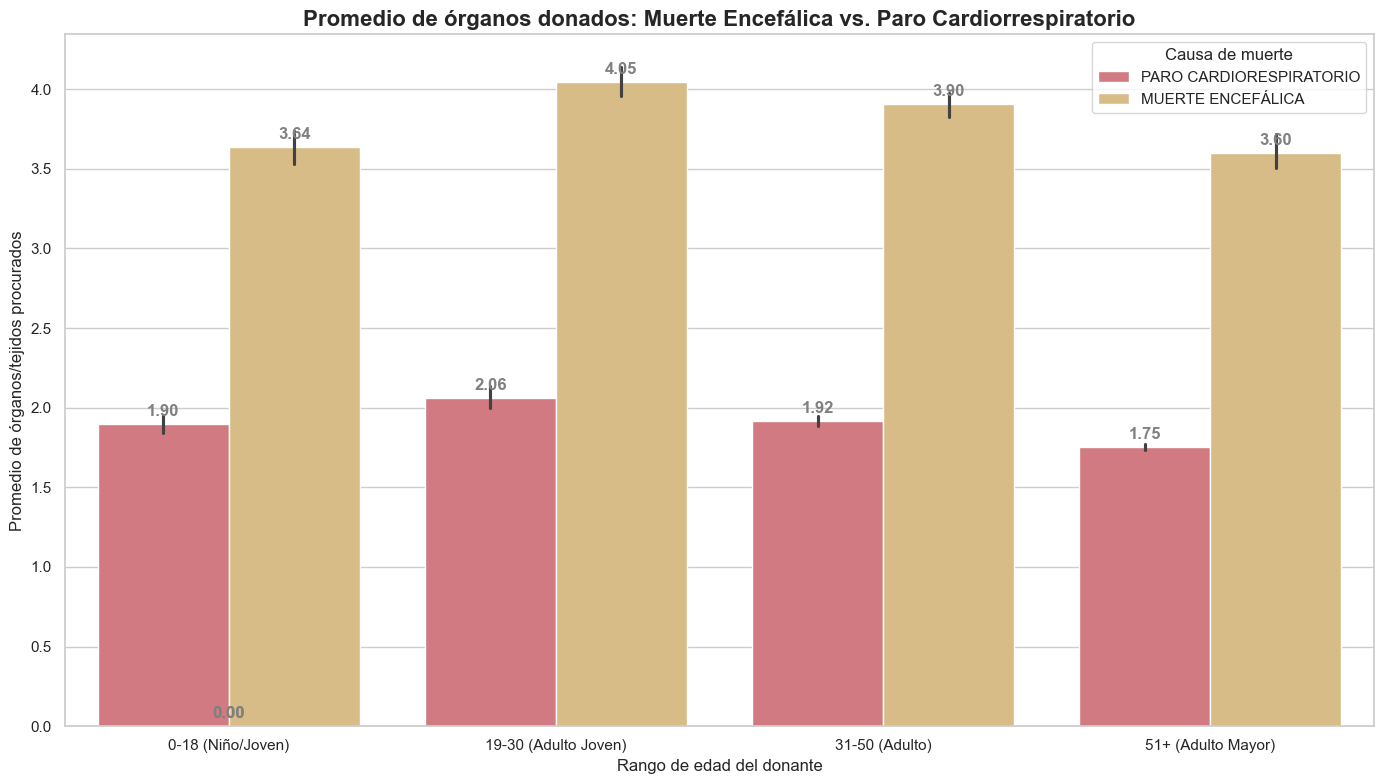

In [66]:
# Definir el tamaño de la figura.
plt.figure(figsize=(14, 8))

# Crear el gráfico de barras agrupado.
ax = sns.barplot(
    data=df_h2,
    x='RANGO_EDAD',         # Eje X: Los rangos de edad
    y='TOTAL_ORGANOS',      # Eje Y: El promedio de órganos
    hue='MUERTE'            # Agrupador: La causa de muerte
)

# --- Mejorar la gráfica ---
ax.set_title('Promedio de órganos donados: Muerte Encefálica vs. Paro Cardiorrespiratorio', fontsize=16, weight='bold')
ax.set_xlabel('Rango de edad del donante', fontsize=12)
ax.set_ylabel('Promedio de órganos/tejidos procurados', fontsize=12)

# Mover la leyenda
ax.legend(title='Causa de muerte', loc='upper right')

# Ciclo 'for' que dibuja el número (promedio) encima de cada barra.
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'),  # Formato con 2 decimales
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                color='gray',
                weight='bold')

plt.tight_layout()
plt.show()

#### Paso H2.3: Interpretación y conclusión de la hipótesis 2

* **Hipótesis:** "Muerte encefálica... presenta una tasa promedio de órganos... más alta que el paro cardiorrespiratorio, independientemente de la edad."

* **Hallazgo:** La gráfica **valida esta hipótesis de forma rotunda**. En *todos* los rangos de edad, la barra de 'MUERTE ENCEFÁLICA' (color amarillo) es significativamente más alta que la de 'PARO CARDIORESPIRATORIO' (color rojo).  **0-18:** 3.64 órganos vs. 1.90, **19-30:** 4.05 órganos vs. 2.06, **31-50:** 3.90 órganos vs. 1.92, **51+:** 3.60 órganos vs. 1.75

* **Conclusión clave:** La 'MUERTE ENCEFÁLICA' permite procurar, en promedio, casi el doble (o más del doble) de órganos que un 'PARO CARDIORESPIRATORIO'. El pico de donación se da en el rango '19-30 (Adulto Joven)' con muerte encefálica, alcanzando un promedio de 4.05 órganos por evento.

**Respuesta a la hipótesis 2:** La hipótesis es **TOTALMENTE VALIDADA**. Los datos confirman que la muerte encefálica es la condición que permite una procuración multi-órgano mucho más exitosa, y esto se cumple en todos los grupos de edad.
- - -

### Hipótesis 3: Tendencia mensual de "Muerte Encefálica" vs. Otras Causas

**Hipótesis textual:** "Se hipotetiza que las donaciones originadas por 'Muerte Encefálica' muestran un incremento significativo durante los periodos vacacionales (diciembre y meses de verano), en contraste con otras causas de donación."

**Mi plan:** 
* 1. Ya analizamos `MUERTE ENCEFÁLICA` en la Pregunta 3. Ahora debemos analizar la otra causa principal, `PARO CARDIORESPIRATORIO`. Filtraremos el DataFrame df para crear uno nuevo solo con esta causa.
* 2. Para comparar tendencias, un **gráfico de líneas (sns.lineplot)** es mejor que un gráfico de barras. Crearemos un gráfico con dos líneas: una para el conteo de 'MUERTE ENCEFÁLICA' por mes y otra para 'PARO CARDIORESPIRATORIO' por mes.
* 3.  Al superponer las dos líneas, podremos ver si los picos e incrementos ocurren en los mismos meses o en meses "en contraste" (diferentes).
- - -

#### **Paso H3.1: Filtrar datos para la hipótesis**

Creamos dos DataFrames separados: uno para 'MUERTE ENCEFÁLICA' y otro para 'PARO CARDIORESPIRATORIO'. Usaremos los mismos que en la Hipótesis 2.

In [67]:
# Definir la lista de causas de muerte a comparar
causas_muerte_h3 = ['MUERTE ENCEFÁLICA', 'PARO CARDIORESPIRATORIO']

# Filtrar el DataFrame
df_h3 = df[df['MUERTE'].isin(causas_muerte_h3)].copy()

# .size() cuenta el número de filas, .reset_index(name='CONTEO') convierte el resultado en un DataFrame
# y nombra la nueva columna de conteo como 'CONTEO'
df_h3_conteo = df_h3.groupby(['MES', 'MUERTE']).size().reset_index(name='CONTEO')

print("Tabla de conteo manual creada:")
print(df_h3_conteo.head())

Tabla de conteo manual creada:
   MES                   MUERTE  CONTEO
0    1        MUERTE ENCEFÁLICA     465
1    1  PARO CARDIORESPIRATORIO    1275
2    2        MUERTE ENCEFÁLICA     470
3    2  PARO CARDIORESPIRATORIO    1275
4    3        MUERTE ENCEFÁLICA     535


#### **Paso H3.2: Generar la Gráfica de Líneas (Tendencia Mensual)**

Usar `sns.lineplot()` sobre nuestro DataFrame filtrado `df_h3`. Esta función calculará automáticamente el conteo total por mes para cada una de las dos causas de muerte y las dibujará como líneas separadas.

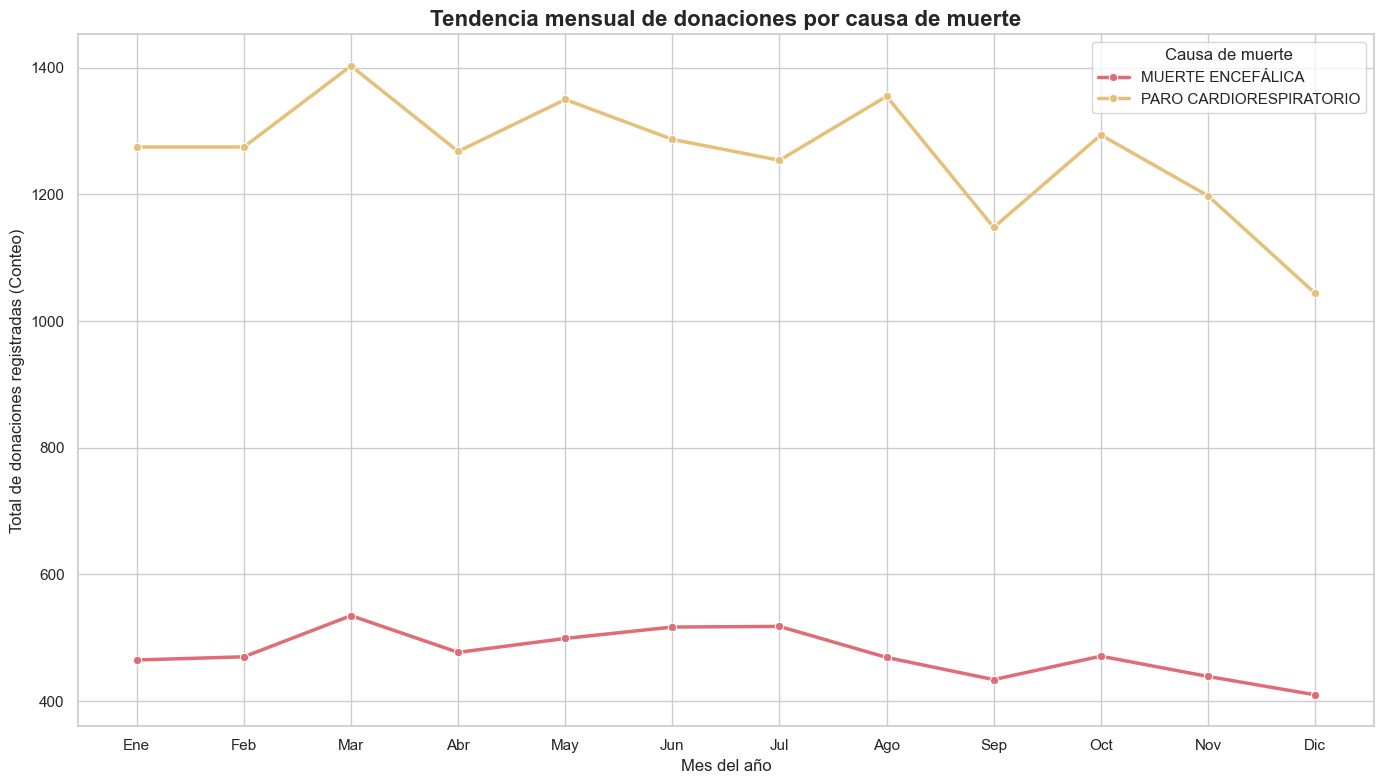

In [68]:
# Definir el tamaño de la figura.
plt.figure(figsize=(14, 8))

# Crear el gráfico de líneas desde nuestro DataFrame pre-contado.
ax = sns.lineplot(
    data=df_h3_conteo,  # Usar el nuevo DataFrame de conteo.
    x='MES',            # Eje X: los meses.
    y='CONTEO',         # Eje Y: nuestra columna de conteo.
    hue='MUERTE',       # Dibujar una línea diferente para cada causa.
    marker='o',         # Poner un círculo en cada punto de dato (mes).
    linewidth=2.5       # Hacer las líneas un poco más gruesas.
)

# --- Mejorar la gráfica ---
ax.set_title('Tendencia mensual de donaciones por causa de muerte', fontsize=16, weight='bold')
ax.set_xlabel('Mes del año', fontsize=12)
ax.set_ylabel('Total de donaciones registradas (Conteo)', fontsize=12)

# Asegurar que el eje X muestre los 12 meses.
plt.xticks(ticks=range(1, 13)) 
# Definir las etiquetas de texto para el eje X.
meses_labels = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
ax.set_xticklabels(meses_labels)

ax.legend(title='Causa de muerte', loc='upper right')

plt.tight_layout()
plt.show()

#### Paso H3.3: Interpretación y Conclusión de la Hipótesis 3

* **Hipótesis:** "'Muerte Encefálica' muestra un incremento en verano y diciembre, en contraste con otras causas."

* **Hallazgo 1 (verano y diciembre):** La gráfica refuta la primera parte de la hipótesis. La línea de **'MUERTE ENCEFÁLICA'** (amarilla) NO muestra un incremento en **Diciembre**; de hecho, es su punto más bajo del año. En verano (Jun-Jul-Ago), muestra un pequeño pico en Junio, seguido de una baja, no un incremento sostenido.

* **Hallazgo 2 (contraste):** La gráfica también refuta la segunda parte de la hipótesis. Las dos líneas NO están "en contraste". Al contrario, siguen un patrón estacional (tendencia) casi idéntico. Ambas líneas tienen su pico más alto en **Marzo**, ambas bajan en **Abril**, ambas suben en **Mayo**, y ambas tienen sus puntos más bajos en **Diciembre**.

**Respuesta a la hipótesis 3:** La hipótesis es **TOTALMENTE RECHAZADA**. Los datos no muestran un incremento de 'Muerte Encefálica' en los periodos vacacionales clave. Además, su tendencia mensual no está en contraste con la de 'Paro Cardiorrespiratorio'; por el contrario, ambas causas de muerte siguen un patrón estacional muy similar a lo largo del año, sugiriendo que un factor externo (distinto a la causa de muerte) podría estar influyendo en las donaciones.
- - -

### Resumen y puntos clave del EDA
- El dataset contiene información sobre donaciones de órganos en México, con múltiples variables que incluyen fecha de procuración, tipo de órgano, estado, hospital, edad del donante y causa de muerte.
- La mayoría de los eventos de donación involucran entre 1 y 2 órganos, aunque los donantes con muerte encefálica presentan promedios significativamente más altos (entre 3.6 y 4.05 órganos por evento).
- Las variables relacionadas con órganos y causa de muerte muestran correlaciones positivas, especialmente entre muerte encefálica y mayor número de órganos procurados.
- Las tendencias mensuales de donaciones por causa de muerte son similares, con picos en marzo y bajas en diciembre, lo que sugiere un patrón estacional común independiente de la causa de muerte.
- El rango de edad 19-30 años (Adulto Joven) con muerte encefálica presenta el promedio más alto de órganos procurados (4.05 órganos por donación).
- No se observan outliers extremos en la variable TOTAL_ORGANOS según los análisis realizados.